Pairs: 10731 CA-CA distances (fixed)
Loading BioEmu features...
BioEmu features shape: (20, 10731)
Dynamic contacts kept: 169 / 10731
Training robust SFA on BioEmu (your generalized-eigen SFA)...
Selected eigenvalues (slowest): [-1.65494344e-08 -1.46497461e-08]
Projecting MD trajectories...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  MD 000: 999 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  MD 001: 999 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  MD 002: 999 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  MD 003: 999 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and l

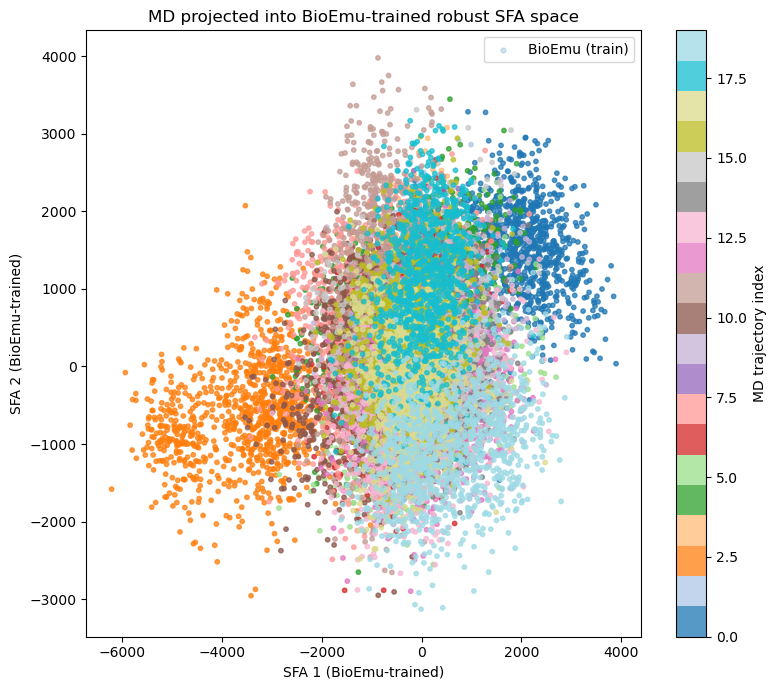

In [ ]:
import os
import glob
import numpy as np
import mdtraj as md
import scipy.linalg
import matplotlib.pyplot as plt


def compute_switching_function(distances: np.ndarray, r_decay: float = 0.90, n: int = 6) -> np.ndarray:
    return 1.0 / (1.0 + (distances / r_decay) ** n)

def build_ca_pairs_from_pdb(pdb_path: str) -> np.ndarray:
    t0 = md.load(pdb_path)
    ca = t0.topology.select("name CA")
    if len(ca) == 0:
        raise ValueError(f"No CA atoms found in topology from {pdb_path}")
    n_ca = len(ca)
    pairs = [(ca[i], ca[j]) for i in range(n_ca) for j in range(i + 1, n_ca)]
    return np.array(pairs, dtype=int)

def get_contact_features(traj_path: str, top_path: str, pairs: np.ndarray,
                         r_decay: float = 0.90, n_power: int = 6,
                         skip_first_frame: bool = False) -> np.ndarray:
    t = md.load(traj_path, top=top_path)
    if skip_first_frame:
        if t.n_frames > 1:
            t = t[1:]
        else:
            print(f"Warning: {traj_path} has only 1 frame; cannot skip.")
    d = md.compute_distances(t, pairs)  # nm
    s = compute_switching_function(d, r_decay=r_decay, n=n_power)
    return s

def fit_robust_sfa_model(data: np.ndarray, n_components: int = 2, epsilon: float = 1e-8):
    mean = np.mean(data, axis=0)
    Xc = data - mean

    C = np.cov(Xc, rowvar=False)
    C += np.eye(C.shape[0]) * epsilon

    dX = Xc[1:] - Xc[:-1]
    H = np.cov(dX, rowvar=False)

    evals, evecs = scipy.linalg.eigh(H, C)
    idx = np.argsort(evals)  # smallest = slowest
    W = evecs[:, idx[:n_components]]
    return mean, W, evals[idx[:n_components]]


def transform_with_sfa_model(data: np.ndarray, mean: np.ndarray, W: np.ndarray) -> np.ndarray:
    return (data - mean) @ W

# Change for your files when replicating our results
bioemu_glob = "/home/tomgolf/GITHUB/MyProjects/Diploma_Thesis/06_bioemu/musM_OBP5/clustering/centers/*.pdb"
md_root = "/home/tomgolf/GITHUB/MyProjects/Diploma_Thesis/06_bioemu/musM_OBP5/MDs/md_results"
n_md = 20

# SFA/contact params
r_decay = 0.90
n_power = 6
n_sfa = 2

skip_first_md_frame = True

bioemu_files = sorted(glob.glob(bioemu_glob))
if not bioemu_files:
    raise FileNotFoundError(f"No BioEmu files found: {bioemu_glob}")

pairs = build_ca_pairs_from_pdb(bioemu_files[0])
print(f"Pairs: {pairs.shape[0]} CA-CA distances (fixed)")

print("Loading BioEmu features...")
bioemu_feats = []
for f in bioemu_files:
    s = get_contact_features(f, f, pairs, r_decay=r_decay, n_power=n_power, skip_first_frame=False)
    bioemu_feats.append(s)
bioemu_feats = np.vstack(bioemu_feats)  # (n_pdbs, n_pairs)
print("BioEmu features shape:", bioemu_feats.shape)


min_s = np.min(bioemu_feats, axis=0)
max_s = np.max(bioemu_feats, axis=0)
mask = (min_s < 0.4) & (max_s > 0.6)
kept_idx = np.where(mask)[0]
print(f"Dynamic contacts kept: {mask.sum()} / {bioemu_feats.shape[1]}")

if mask.sum() < 2:
    raise RuntimeError("Not enough dynamic contacts for SFA under the BioEmu mask.")

bioemu_filt = bioemu_feats[:, mask]

print("Training robust SFA on BioEmu (your generalized-eigen SFA)...")
mean, W, evals = fit_robust_sfa_model(bioemu_filt, n_components=n_sfa)
print("Selected eigenvalues (slowest):", evals)

bioemu_proj = transform_with_sfa_model(bioemu_filt, mean, W)

md_proj_list = []
md_id_list = []

print("Projecting MD trajectories...")
for i in range(n_md):
    folder = os.path.join(md_root, f"cluster_center_{i:03d}")
    traj = os.path.join(folder, "trajectory.dcd")
    top = os.path.join(folder, "equilibrated.pdb")
    if not (os.path.exists(traj) and os.path.exists(top)):
        continue

    md_feats = get_contact_features(
        traj, top, pairs, r_decay=r_decay, n_power=n_power, skip_first_frame=skip_first_md_frame
    )
    md_feats = md_feats[:, mask]  # apply BioEmu mask
    proj = transform_with_sfa_model(md_feats, mean, W)

    md_proj_list.append(proj)
    md_id_list.append(np.full(proj.shape[0], i, dtype=int))
    print(f"  MD {i:03d}: {proj.shape[0]} frames")

if not md_proj_list:
    raise FileNotFoundError("No MD trajectories projected (check md_root/path pattern).")

md_proj_all = np.vstack(md_proj_list)
md_id_all = np.concatenate(md_id_list)


In [9]:
set(md_id_all)

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19)}

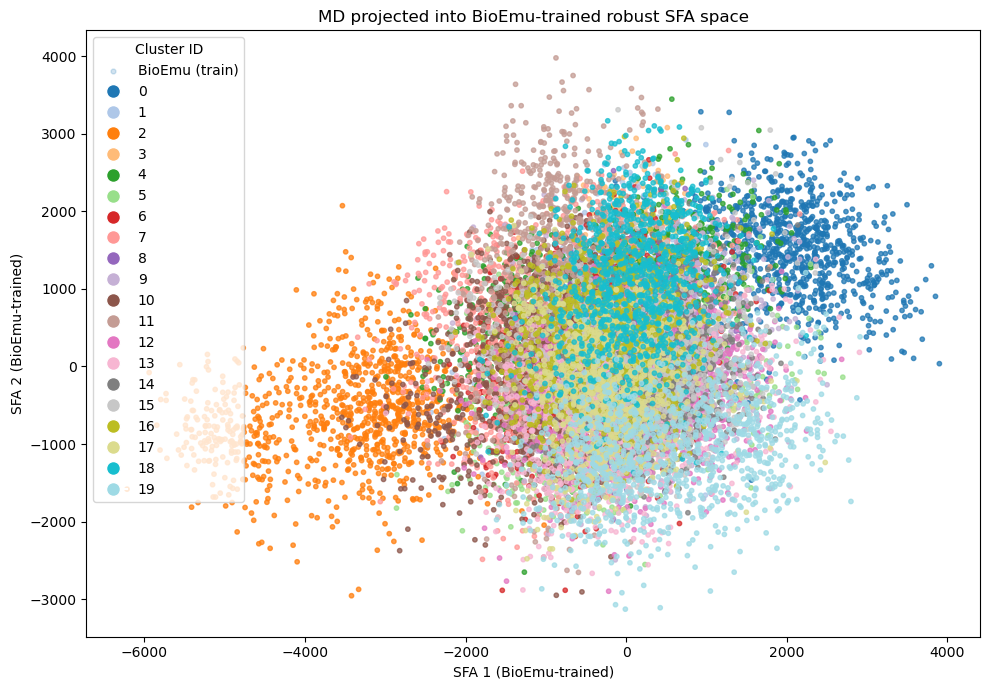

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(10, 7))

plt.scatter(bioemu_proj[:, 0], bioemu_proj[:, 1], s=12, alpha=0.2, label="BioEmu (train)")

cmap = plt.get_cmap("tab20")
sc = plt.scatter(md_proj_all[:, 0], md_proj_all[:, 1], c=md_id_all, s=10, alpha=0.75, cmap=cmap)
unique_ids = np.unique(md_id_all)

custom_handles = []
for uid in unique_ids:
    color = sc.to_rgba(uid)    
    handle = Line2D(
        [0], [0], 
        marker='o', 
        color='w', 
        markerfacecolor=color, 
        markersize=10, 
        label=str(int(uid))
    )
    custom_handles.append(handle)

h_existing, l_existing = plt.gca().get_legend_handles_labels()

plt.legend(
    handles=h_existing + custom_handles, 
    title="Cluster ID", 
    loc="best"
)

plt.xlabel("SFA 1 (BioEmu-trained)")
plt.ylabel("SFA 2 (BioEmu-trained)")
plt.title("MD projected into BioEmu-trained robust SFA space")
plt.tight_layout()
plt.show()

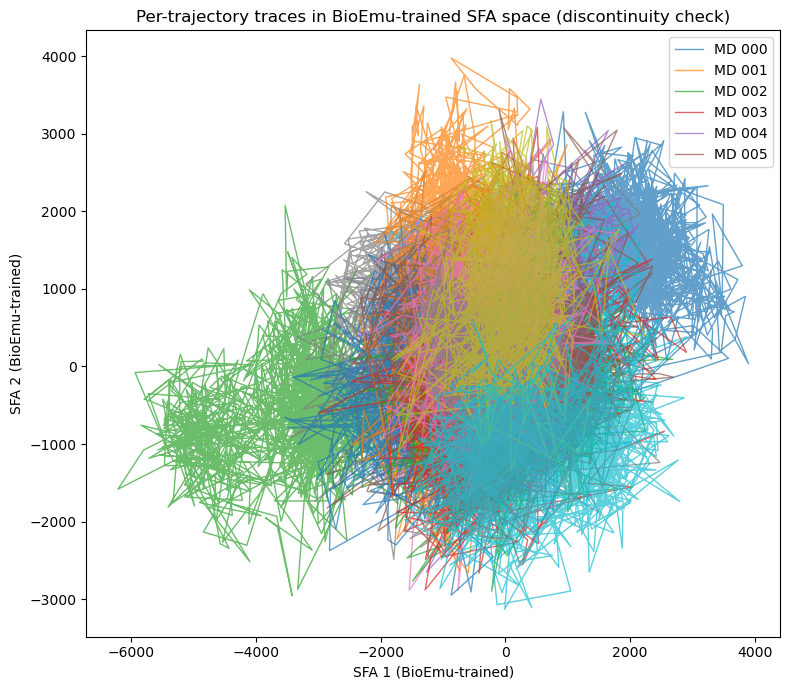


Simple discontinuity report (largest step per trajectory):
  MD 000: max step = 2835.9990, 99% step = 1900.6992
  MD 001: max step = 2749.9042, 99% step = 2133.2866
  MD 002: max step = 2758.0510, 99% step = 1827.5875
  MD 003: max step = 2155.6982, 99% step = 1713.3209
  MD 004: max step = 3963.1530, 99% step = 2736.6798
  MD 005: max step = 3547.6394, 99% step = 2446.5129
  MD 006: max step = 3643.1315, 99% step = 2405.2221
  MD 007: max step = 3259.8684, 99% step = 2545.7952
  MD 008: max step = 1833.0458, 99% step = 1432.7269
  MD 009: max step = 3416.1526, 99% step = 2548.2570
  MD 010: max step = 3309.7857, 99% step = 2002.4989
  MD 011: max step = 3282.5158, 99% step = 1902.4162
  MD 012: max step = 3118.3869, 99% step = 2528.2364
  MD 013: max step = 3240.7977, 99% step = 2364.2994
  MD 014: max step = 2244.4816, 99% step = 1816.4117
  MD 015: max step = 2854.5957, 99% step = 2033.1367
  MD 016: max step = 2408.9285, 99% step = 2051.6941
  MD 017: max step = 2415.3320, 99% ste

In [ ]:


plt.figure(figsize=(8, 7))
for i, proj in enumerate(md_proj_list):
    # Label only a few to avoid legend spam
    lbl = f"MD {i:03d}" if i < 6 else None
    plt.plot(proj[:, 0], proj[:, 1], lw=1.0, alpha=0.7, label=lbl)
plt.xlabel("SFA 1 (BioEmu-trained)")
plt.ylabel("SFA 2 (BioEmu-trained)")
plt.title("Per-trajectory traces in BioEmu-trained SFA space (discontinuity check)")
plt.legend(loc="best")

plt.tight_layout()
plt.show()

print("\nSimple discontinuity report (largest step per trajectory):")
for i, proj in enumerate(md_proj_list):
    if proj.shape[0] < 3:
        continue
    step = np.linalg.norm(proj[1:] - proj[:-1], axis=1)
    print(f"  MD {i:03d}: max step = {step.max():.4f}, 99% step = {np.quantile(step, 0.99):.4f}")



Loading trajectories and computing backbone torsion angles (phi/psi)...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  Loaded traj 0: 1000 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  Loaded traj 1: 1000 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  Loaded traj 2: 1000 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  Loaded traj 3: 1000 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  Loaded traj 4: 1000 frames
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
  Loaded traj 5: 1000 frame

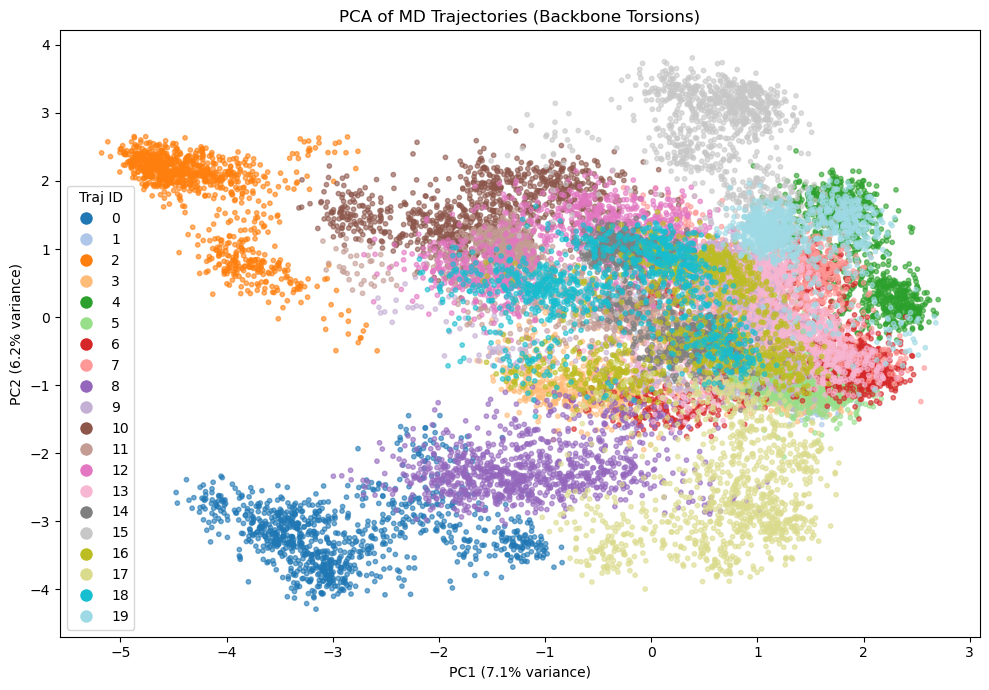

In [ ]:
import os
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

md_root = "/home/tomgolf/GITHUB/MyProjects/Diploma_Thesis/06_bioemu/musM_OBP5/MDs/md_results"
n_trajs = 20 

all_features = []
traj_ids = []

print("Loading trajectories and computing backbone torsion angles (phi/psi)...")

for i in range(n_trajs):
    folder = os.path.join(md_root, f"cluster_center_{i:03d}")
    traj_file = os.path.join(folder, "trajectory.dcd")
    top_file = os.path.join(folder, "equilibrated.pdb")
    
    if not os.path.exists(traj_file):
        continue
        
    t = md.load(traj_file, top=top_file)
    
    _, phi = md.compute_phi(t)
    _, psi = md.compute_psi(t)
    
    phi_feat = np.hstack([np.cos(phi), np.sin(phi)])
    psi_feat = np.hstack([np.cos(psi), np.sin(psi)])
    
    feats = np.hstack([phi_feat, psi_feat])
    
    all_features.append(feats)
    traj_ids.append(np.full(len(feats), i))
    
    print(f"  Loaded traj {i}: {len(feats)} frames")

X_all = np.vstack(all_features)
ids_all = np.concatenate(traj_ids)

print(f"Total frames: {X_all.shape[0]}, Total features: {X_all.shape[1]}")

print("Running PCA...")
pca = PCA(n_components=2)
pca_proj = pca.fit_transform(X_all)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

plt.figure(figsize=(10, 7))

cmap = plt.get_cmap("tab20")

sc = plt.scatter(pca_proj[:, 0], pca_proj[:, 1], c=ids_all, s=10, alpha=0.6, cmap=cmap)

unique_ids = np.unique(ids_all)
custom_handles = []
for uid in unique_ids:
    color = sc.to_rgba(uid)
    handle = Line2D([0], [0], 
                    marker='o', 
                    color='w', 
                    markerfacecolor=color, 
                    markersize=10, 
                    label=str(int(uid)))
    custom_handles.append(handle)

plt.legend(handles=custom_handles, title="Traj ID", loc="best")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of MD Trajectories (Backbone Torsions)")
plt.tight_layout()
plt.show()

Running PCA...
Explained variance ratio: [0.0713845  0.06214951 0.05557665]


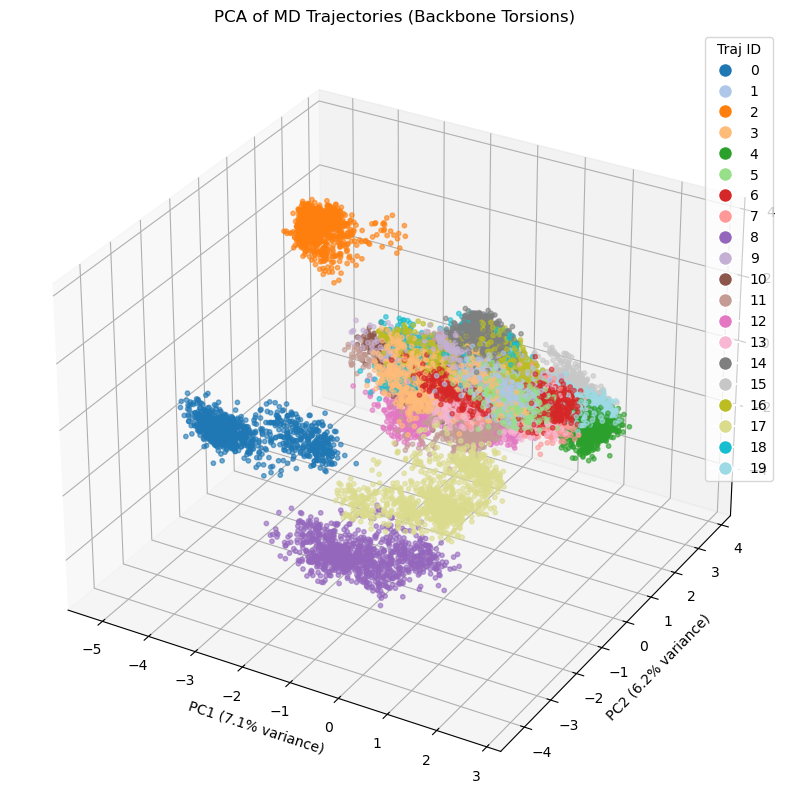

In [ ]:
print("Running PCA...")
pca = PCA(n_components=3)
pca_proj = pca.fit_transform(X_all)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

plt.figure(figsize=(8, 12))
ax = plt.axes(projection='3d')

cmap = plt.get_cmap("tab20")

sc = ax.scatter(pca_proj[:, 0], pca_proj[:, 1], pca_proj[:, 2], c=ids_all, s=10, alpha=0.6, cmap=cmap)

unique_ids = np.unique(ids_all)
custom_handles = []
for uid in unique_ids:
    color = sc.to_rgba(uid)
    handle = Line2D([0], [0], 
                    marker='o', 
                    color='w', 
                    markerfacecolor=color, 
                    markersize=10, 
                    label=str(int(uid)))
    custom_handles.append(handle)

plt.legend(handles=custom_handles, title="Traj ID", loc="best")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of MD Trajectories (Backbone Torsions)")
plt.tight_layout()
plt.show()